**QuickStart:**

In [1]:

import os, json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')
base_path  = '/content/drive/MyDrive/ForensicAudio'
feat_path  = f'{base_path}/features/train'
stats_dir  = f'{base_path}/features'
splits_dir = f'{base_path}/splits'

# 2. Load config
with open(f'{splits_dir}/handover.json') as f:
    config = json.load(f)
print("Config loaded:", json.dumps(config, indent=2))

# 3. Load splits
train_df = pd.read_csv(f'{splits_dir}/train_df.csv')
val_df   = pd.read_csv(f'{splits_dir}/val_df.csv')
print(f"\nTrain : {len(train_df)} samples")
print(f"Val   : {len(val_df)} samples")

# 4. Load normalization stats
global_mean = np.load(f'{stats_dir}/global_mean.npy')
global_std  = np.load(f'{stats_dir}/global_std.npy')
print(f"\nMean shape: {global_mean.shape}")
print(f"Std  shape: {global_std.shape}")

# 5. Dataset class
class ASVspoofDataset(Dataset):
    def __init__(self, df, feat_dir, global_mean, global_std):
        self.df          = df.reset_index(drop=True)
        self.feat_dir    = feat_dir
        self.global_mean = global_mean.squeeze()
        self.global_std  = global_std.squeeze()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        feat = np.load(os.path.join(
                   self.feat_dir, row['file_id'] + '.npy'))
        feat = (feat - self.global_mean[:, None]) / \
               (self.global_std[:, None] + 1e-8)
        feat_tensor  = torch.FloatTensor(feat).unsqueeze(0)
        label_tensor = torch.tensor(row['binary_label'], dtype=torch.long)
        return feat_tensor, label_tensor

# 6. Sampler
def get_sampler(df):
    n_bonafide     = (df['binary_label'] == 0).sum()
    n_spoof        = (df['binary_label'] == 1).sum()
    sample_weights = df['binary_label'].map(
        {0: 1.0/n_bonafide, 1: 1.0/n_spoof}
    ).values
    return WeightedRandomSampler(
        weights     = torch.FloatTensor(sample_weights),
        num_samples = len(sample_weights),
        replacement = True
    )

# 7. DataLoaders
train_dataset = ASVspoofDataset(train_df, feat_path, global_mean, global_std)
val_dataset   = ASVspoofDataset(val_df,   feat_path, global_mean, global_std)

Train_loader  = DataLoader(
    train_dataset, batch_size=32,
    sampler=get_sampler(train_df), num_workers=0
)
Val_loader    = DataLoader(
    val_dataset, batch_size=32,
    shuffle=False, num_workers=0
)

# 8. Verify
batch_feat, batch_label = next(iter(Train_loader))
print(f"Batch shape     : {batch_feat.shape}")
print(f"Feature range   : {batch_feat.min():.2f} → {batch_feat.max():.2f}")
print(f"Label balance   : {batch_label.bincount()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config loaded: {
  "total_samples": 25380,
  "train_samples": 22842,
  "val_samples": 2538,
  "feature_shape": "(20, 300)",
  "n_lfcc": 20,
  "n_filter": 70,
  "n_fft": 512,
  "win_length": 400,
  "hop_length": 160,
  "sr": 16000,
  "max_frames": 300,
  "batch_size": 32,
  "label_0": "bonafide",
  "label_1": "spoof",
  "feat_dir": "/content/drive/MyDrive/ForensicAudio/features/train",
  "stats_dir": "/content/drive/MyDrive/ForensicAudio/features",
  "splits_dir": "/content/drive/MyDrive/ForensicAudio/splits"
}

Train : 22842 samples
Val   : 2538 samples

Mean shape: (1, 20, 1)
Std  shape: (1, 20, 1)
Batch shape     : torch.Size([32, 1, 20, 300])
Feature range   : -5.47 → 5.16
Label balance   : tensor([13, 19])


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


**CNN Block**

In [4]:
class CNNBLOCK(nn.Module):
  def __init__(self):
    super(CNNBLOCK,self).__init__()
    self.conv1=nn.Sequential(
        nn.Conv2d(1,32,3,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )
    self.conv2=nn.Sequential(
        nn.Conv2d(32,64,3,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )
    self.conv3=nn.Sequential(
        nn.Conv2d(64,128,3,padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((1,None))
    )
  def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)
        return x

**BiLSTM Block**

In [5]:
class BILSTMBLOCK(nn.Module):
  def __init__(self,in_size=128,hid_size=128,num_layers=2,dropout=0.3):
    super(BILSTMBLOCK,self).__init__()
    self.lstm=nn.LSTM(
        input_size=in_size,
        hidden_size=hid_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=dropout,
        bidirectional=True
    )
    self.dropout = nn.Dropout(dropout)
  def forward(self,x):
    out, _ = self.lstm(x)
    out    = out[:, -1, :]
    out    = self.dropout(out)
    return out

**Classification Block**

In [6]:
class CLASIFIERHEAD(nn.Module):
  def __init__(self,in_size=256,num_classes=2,dropout=0.3):
    super(CLASIFIERHEAD,self).__init__()
    self.classifier=nn.Sequential(
        nn.Linear(in_size,64),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(64,num_classes)
    )
  def forward(self,x):
    return self.classifier(x)

**Full Model Block**

In [7]:
class CNNLSTMMODEL(nn.Module):
  def __init__(self):
    super(CNNLSTMMODEL,self).__init__()
    self.cnn=CNNBLOCK()
    self.lstm=BILSTMBLOCK()
    self.classifier=CLASIFIERHEAD()
  def forward(self,x):
    x=self.cnn(x)
    x=self.lstm(x)
    x=self.classifier(x)
    return x

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = CNNLSTMMODEL().to(device)
print(f"Device : {device}")
print(f"\n{model}")

Device : cpu

CNNLSTMMODEL(
  (cnn): CNNBLOCK(
    (conv1): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (conv3): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): AdaptiveAvgPool2d(output_size=(1, None))
    )
  )
  (lstm): BILSTMBLOCK(
    (lstm): LSTM(128, 128, num_layers=2, batch_fir

In [9]:
# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Forward pass with real batch
model.eval()
with torch.no_grad():
    sample_input = batch_feat.to(device)
    output       = model(sample_input)
    probs        = torch.softmax(output, dim=1)

print(f"\nInput shape : {sample_input.shape}")
print(f"Output shape: {output.shape}")
print(f"\nSample predictions (first 5) — random before training:")
for i in range(5):
    print(f"  [{i}] bonafide: {probs[i][0]:.3f} | "
          f"spoof: {probs[i][1]:.3f} | "
          f"pred: {'SPOOF' if probs[i][1] > 0.5 else 'BONAFIDE'}")

Total params    : 769,154
Trainable params: 769,154

Input shape : torch.Size([32, 1, 20, 300])
Output shape: torch.Size([32, 2])

Sample predictions (first 5) — random before training:
  [0] bonafide: 0.462 | spoof: 0.538 | pred: SPOOF
  [1] bonafide: 0.462 | spoof: 0.538 | pred: SPOOF
  [2] bonafide: 0.462 | spoof: 0.538 | pred: SPOOF
  [3] bonafide: 0.462 | spoof: 0.538 | pred: SPOOF
  [4] bonafide: 0.462 | spoof: 0.538 | pred: SPOOF


**Adressing class imbalance,Lose and Optemizer**

In [10]:
from sklearn.utils.class_weight import compute_class_weight


classes      = np.array([0, 1])
weights      = compute_class_weight('balanced',
                                     classes=classes,
                                     y=train_df['binary_label'].values)
class_weights = torch.FloatTensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"Class weights → bonafide: {weights[0]:.2f} | spoof: {weights[1]:.2f}")
print(f"Criterion : CrossEntropyLoss with class weights")
print(f"Optimizer : Adam (lr=1e-3)")
print(f"Scheduler : ReduceLROnPlateau (patience=3)")

KeyboardInterrupt: 

**Training Loop**

In [ ]:
# Training Loop
NUM_EPOCHS    = 20
best_val_loss = float('inf')
patience      = 5       # early stopping patience
no_improve    = 0       # counter
history       = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

models_dir = f'{base_path}/models'
os.makedirs(models_dir, exist_ok=True)

for epoch in range(NUM_EPOCHS):

    # ── TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch_feat, batch_label in Train_loader:
        batch_feat  = batch_feat.to(device)
        batch_label = batch_label.to(device)

        optimizer.zero_grad()           # clear previous gradients
        output = model(batch_feat)      # forward pass
        loss   = criterion(output, batch_label)  # compute loss
        loss.backward()                 # backpropagation
        optimizer.step()                # update weights

        # Track metrics
        train_loss    += loss.item()
        preds          = output.argmax(dim=1)
        train_correct += (preds == batch_label).sum().item()
        train_total   += batch_label.size(0)

    avg_train_loss = train_loss / len(Train_loader)
    avg_train_acc  = train_correct / train_total

    # ── VALIDATE
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch_feat, batch_label in Val_loader:
            batch_feat  = batch_feat.to(device)
            batch_label = batch_label.to(device)

            output = model(batch_feat)
            loss   = criterion(output, batch_label)

            val_loss    += loss.item()
            preds        = output.argmax(dim=1)
            val_correct += (preds == batch_label).sum().item()
            val_total   += batch_label.size(0)

    avg_val_loss = val_loss / len(Val_loader)
    avg_val_acc  = val_correct / val_total

    # ── SCHEDULER
    scheduler.step(avg_val_loss)

    # ── HISTORY
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)

    # ── CHECKPOINT
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        no_improve    = 0
        torch.save(model.state_dict(),
                   f'{models_dir}/best_model.pth')
        saved = " saved"
    else:
        no_improve += 1
        saved       = ""

    # ── LOG ────────────────────────────────────────────
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Train Acc: {avg_train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {avg_val_acc:.4f} "
          f"{saved}")

    # ── EARLY STOPPING ─────────────────────────────────
    if no_improve >= patience:
        print(f"\n⚠️ Early stopping at epoch {epoch+1} "
              f"— no improvement for {patience} epochs")
        break

print(f"\n Training complete!")
print(f" Best val loss : {best_val_loss:.4f}")
print(f" Best model saved to {models_dir}/best_model.pth")

KeyboardInterrupt: 

In [11]:
# Load best model from Drive
models_dir = f'{base_path}/models'

model = CNNLSTMMODEL().to(device)
model.load_state_dict(
    torch.load(f'{models_dir}/best_model.pth',
               map_location=device)
)
model.eval()
print(f" Model loaded from {models_dir}/best_model.pth")
print(f" Device: {device}")

# Quick sanity check
with torch.no_grad():
    sample = batch_feat.to(device)
    output = model(sample)
    probs  = torch.softmax(output, dim=1)

print(f"\nSanity check — first 3 predictions:")
for i in range(3):
    print(f"  [{i}] bonafide: {probs[i][0]:.3f} | "
          f"spoof: {probs[i][1]:.3f} | "
          f"pred: {'SPOOF' if probs[i][1] > 0.5 else 'BONAFIDE'}")

 Model loaded from /content/drive/MyDrive/ForensicAudio/models/best_model.pth
 Device: cpu

Sanity check — first 3 predictions:
  [0] bonafide: 0.000 | spoof: 1.000 | pred: SPOOF
  [1] bonafide: 1.000 | spoof: 0.000 | pred: BONAFIDE
  [2] bonafide: 0.000 | spoof: 1.000 | pred: SPOOF


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for feat, label in Val_loader:
        feat   = feat.to(device)
        output = model(feat)
        preds  = output.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(label.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(f"                  Pred Bonafide  Pred Spoof")
print(f"True Bonafide  :  {cm[0][0]:8d}    {cm[0][1]:8d}")
print(f"True Spoof     :  {cm[1][0]:8d}    {cm[1][1]:8d}")

# Classification report
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds,
      target_names=['bonafide', 'spoof']))

# Prediction distribution
unique, counts = np.unique(all_preds, return_counts=True)
print(f"Prediction distribution:")
for u, c in zip(unique, counts):
    lbl = 'bonafide' if u == 0 else 'spoof'
    print(f"  {lbl}: {c} ({c/len(all_preds)*100:.1f}%)")

KeyboardInterrupt: 

In [12]:
import os, json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.fft import dct
import librosa
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

In [13]:
dev_audio    = f'{base_path}/ASVspoof2019_LA_dev/flac'
dev_protocol = f'{base_path}/ASVspoof2019_LA_dev/ASVspoof2019.LA.cm.dev.trl.txt'
stats_dir    = f'{base_path}/features'
models_dir   = f'{base_path}/models'
dev_feat_dir = f'{base_path}/features/dev'
os.makedirs(dev_feat_dir, exist_ok=True)

In [14]:
global_mean = np.load(f'{stats_dir}/global_mean.npy')
global_std  = np.load(f'{stats_dir}/global_std.npy')


In [15]:
dev_df = pd.read_csv(dev_protocol, sep=' ', header=None,
                     names=['speaker_id','file_id','system_id','key','label'])
dev_df['filepath']     = dev_df['file_id'].apply(
                            lambda x: os.path.join(dev_audio, x + '.flac'))
dev_df['binary_label'] = (dev_df['label'] == 'spoof').astype(int)

print(f"Dev samples : {len(dev_df)}")
print(f"Label dist  :\n{dev_df['label'].value_counts()}")
print(f"Attack types:\n{dev_df['system_id'].value_counts()}")


Dev samples : 24844
Label dist  :
label
spoof       22296
bonafide     2548
Name: count, dtype: int64
Attack types:
system_id
-    24844
Name: count, dtype: int64


In [ ]:
def lfcc_extraction(filepath, n_lfcc=20, n_filter=70, n_fft=512,
                    win_length=400, hop_length=160, sr=16000, max_frames=300):
    y, _ = librosa.load(filepath, sr=sr, mono=True)
    target_len = sr * 3
    y = np.pad(y, (0, max(0, target_len - len(y))))[:target_len]
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])
    S = np.abs(librosa.stft(y, n_fft=n_fft,
                             hop_length=hop_length,
                             win_length=win_length)) ** 2
    freq_bins  = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    linear_fb  = np.zeros((n_filter, len(freq_bins)))
    freq_points = np.linspace(0, sr/2, n_filter + 2)
    for i in range(n_filter):
        start, center, end = freq_points[i], freq_points[i+1], freq_points[i+2]
        for j, f in enumerate(freq_bins):
            if start <= f <= center:
                linear_fb[i,j] = (f - start)   / (center - start + 1e-8)
            elif center < f <= end:
                linear_fb[i,j] = (end   - f)   / (end - center  + 1e-8)
    filter_energies = np.dot(linear_fb, S)
    log_energies    = np.log(filter_energies + 1e-8)
    lfcc            = dct(log_energies, type=2, axis=0)[:n_lfcc]
    if lfcc.shape[1] < max_frames:
        lfcc = np.pad(lfcc, ((0,0),(0, max_frames - lfcc.shape[1])))
    else:
        lfcc = lfcc[:, :max_frames]
    return lfcc

In [ ]:
def process_single_file(row):
    out_path = os.path.join(dev_feat_dir, row['file_id'] + '.npy')
    if os.path.exists(out_path):
        return row['file_id'], None
    try:
        lfcc = lfcc_extraction(row['filepath'])
        np.save(out_path, lfcc)
        return row['file_id'], None
    except Exception as e:
        return row['file_id'], str(e)

rows   = [row for _, row in dev_df.iterrows()]
failed = []
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(process_single_file, r): r for r in rows}
    for future in tqdm(as_completed(futures), total=len(rows),
                       desc="Extracting dev LFCC"):
        fid, err = future.result()
        if err:
            failed.append((fid, err))

print(f"\nExtracted : {len(os.listdir(dev_feat_dir))} files")
print(f"Failed    : {len(failed)}")


Extracting dev LFCC: 100%|██████████| 24844/24844 [44:24<00:00,  9.32it/s]



Extracted : 24844 files
Failed    : 0


In [16]:
class ASVspoofDataset(Dataset):
    def __init__(self, df, feat_dir, global_mean, global_std):
        self.df          = df.reset_index(drop=True)
        self.feat_dir    = feat_dir
        self.global_mean = global_mean.squeeze()
        self.global_std  = global_std.squeeze()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        feat = np.load(os.path.join(self.feat_dir, row['file_id'] + '.npy'))
        feat = (feat - self.global_mean[:, None]) / (self.global_std[:, None] + 1e-8)
        return torch.FloatTensor(feat).unsqueeze(0), \
               torch.tensor(row['binary_label'], dtype=torch.long)

dev_loader = DataLoader(
    ASVspoofDataset(dev_df, dev_feat_dir, global_mean, global_std),
    batch_size=32, shuffle=False, num_workers=2
)


In [17]:
all_preds,all_labels,all_scores = [],[],[]
model.eval()
with torch.no_grad():
    for feat,label in tqdm(dev_loader,desc="Testing"):
        out   = model(feat.to(device))
        probs = torch.softmax(out,dim=1)
        all_scores.extend(probs[:,1].cpu().numpy())
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(label.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_scores = np.array(all_scores)

Testing: 100%|██████████| 777/777 [55:39<00:00,  4.30s/it]


In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels, all_scores, pos_label=1)
fnr         = 1 - tpr
eer_idx     = np.argmin(np.abs(fpr - fnr))
eer         = (fpr[eer_idx] + fnr[eer_idx]) / 2

print(f"EER    : {eer*100:.2f}%")
print(f"Target : < 5%")
print(f"Result : {'PASSED' if eer*100 < 5 else  'NEEDS IMPROVEMENT'}")

EER    : 0.09%
Target : < 5%
Result : PASSED


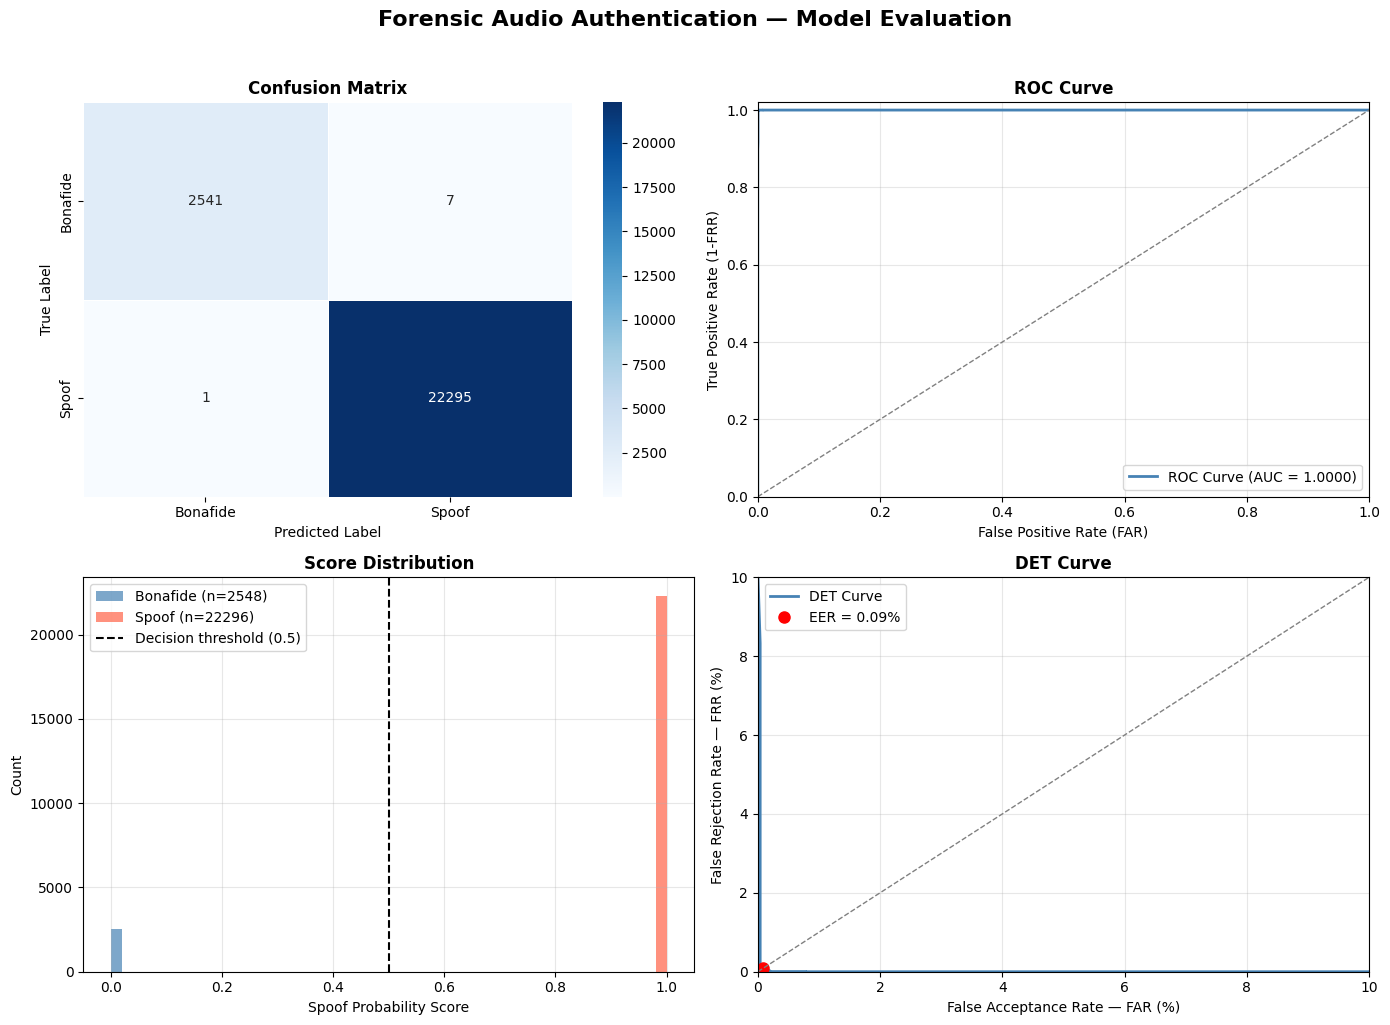

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Forensic Audio Authentication — Model Evaluation',
             fontsize=16, fontweight='bold', y=1.02)
ax1 = axes[0, 0]
cm=confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bonafide', 'Spoof'],
            yticklabels=['Bonafide', 'Spoof'],
            ax=ax1, linewidths=0.5)
ax1.set_title('Confusion Matrix', fontweight='bold')

ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')


ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(all_labels, all_scores, pos_label=1)
roc_auc     = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])
ax2.set_xlabel('False Positive Rate (FAR)')
ax2.set_ylabel('True Positive Rate (1-FRR)')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)


ax3 = axes[1, 0]
bonafide_scores = all_scores[all_labels == 0]
spoof_scores    = all_scores[all_labels == 1]
ax3.hist(bonafide_scores, bins=50, alpha=0.7,
         color='steelblue', label=f'Bonafide (n={len(bonafide_scores)})')
ax3.hist(spoof_scores,    bins=50, alpha=0.7,
         color='tomato',   label=f'Spoof (n={len(spoof_scores)})')
ax3.axvline(x=0.5, color='black', linestyle='--',
            lw=1.5, label='Decision threshold (0.5)')
ax3.set_xlabel('Spoof Probability Score')
ax3.set_ylabel('Count')
ax3.set_title('Score Distribution', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
fnr  = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2
ax4.plot(fpr * 100, fnr * 100, color='steelblue', lw=2, label='DET Curve')
ax4.plot([eer*100], [eer*100], 'ro', markersize=8,
         label=f'EER = {eer*100:.2f}%')
ax4.plot([0,100],[0,100], color='gray', linestyle='--', lw=1)
ax4.set_xlabel('False Acceptance Rate — FAR (%)')
ax4.set_ylabel('False Rejection Rate — FRR (%)')
ax4.set_title('DET Curve', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)
ax4.set_xlim([0, 10])
ax4.set_ylim([0, 10])

plt.tight_layout()


plt.show()

In [29]:
plots_dir = '/content/drive/MyDrive/ForensicAudio/plots'
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(f'{plots_dir}/evaluation_plots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved to Drive!")

<Figure size 640x480 with 0 Axes>

Plots saved to Drive!
